              K-MEANS CLUSTERING
              MALL CUSTOMERS DATASET

First 5 rows:
   CustomerID  Age  Annual_Income  Spending_Score
0           1   19             15              39
1           2   21             16              81
2           3   20             17               6
3           4   23             18              77
4           5   31             19              40

Dataset Shape:
(30, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      30 non-null     int64
 1   Age             30 non-null     int64
 2   Annual_Income   30 non-null     int64
 3   Spending_Score  30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB
None

Features used for clustering:
   Annual_Income  Spending_Score
0             15              39
1             16              81
2             17               6
3  

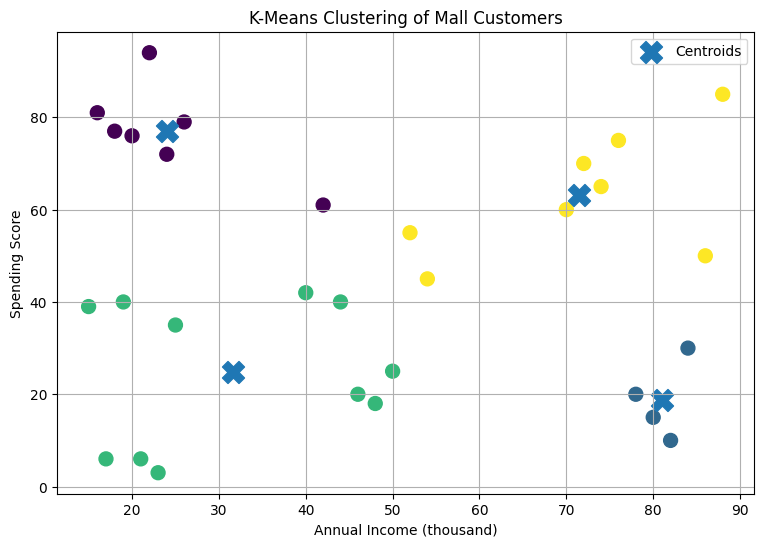

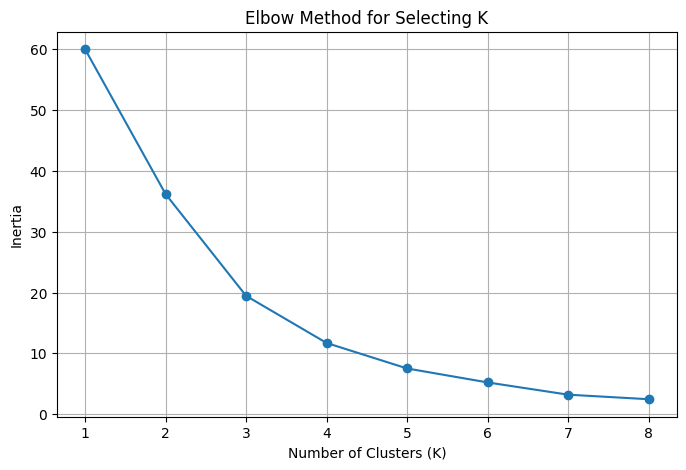


                CUSTOMER GROUPS

Cluster 0:
 CustomerID  Age  Annual_Income  Spending_Score
          2   21             16              81
          4   23             18              77
          6   22             20              76
          8   40             22              94
         10   28             24              72
         12   24             26              79
         14   33             42              61

Cluster 1:
 CustomerID  Age  Annual_Income  Spending_Score
         25   55             78              20
         26   58             80              15
         27   60             82              10
         28   41             84              30

Cluster 2:
 CustomerID  Age  Annual_Income  Spending_Score
          1   19             15              39
          3   20             17               6
          5   31             19              40
          7   35             21               6
          9   30             23               3
         11   25   

In [1]:
# ============================================================================
#              K-MEANS CLUSTERING
#              MALL CUSTOMERS DATASET
# ============================================================================

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# ============================================================================
# SECTION 1 : CREATE DATASET
# ============================================================================

# Customer information:
# Age, Annual Income (in thousands), Spending Score

data = {
    "CustomerID": [
        1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        21, 22, 23, 24, 25, 26, 27, 28, 29, 30
    ],

    "Age": [
        19, 21, 20, 23, 31, 22, 35, 40, 30, 28,
        25, 24, 45, 33, 27, 50, 48, 52, 38, 29,
        32, 36, 42, 46, 55, 58, 60, 41, 34, 26
    ],

    "Annual_Income": [
        15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
        25, 26, 40, 42, 44, 46, 48, 50, 52, 54,
        70, 72, 74, 76, 78, 80, 82, 84, 86, 88
    ],

    "Spending_Score": [
        39, 81, 6, 77, 40, 76, 6, 94, 3, 72,
        35, 79, 42, 61, 40, 20, 18, 25, 55, 45,
        60, 70, 65, 75, 20, 15, 10, 30, 50, 85
    ]
}

df = pd.DataFrame(data)


# ============================================================================
# SECTION 2 : DISPLAY DATASET
# ============================================================================

print("=" * 70)
print("              K-MEANS CLUSTERING")
print("              MALL CUSTOMERS DATASET")
print("=" * 70)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())


# ============================================================================
# SECTION 3 : SELECT FEATURES
# ============================================================================

# We will cluster customers using:
# Annual Income
# Spending Score

X = df[
    [
        "Annual_Income",
        "Spending_Score"
    ]
]


print("\nFeatures used for clustering:")
print(X.head())


# ============================================================================
# SECTION 4 : STANDARDIZE DATA
# ============================================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print("\nStandardized Data:")
print(X_scaled[:5])


# ============================================================================
# SECTION 5 : K-MEANS CLUSTERING
# ============================================================================

# We want 4 customer groups

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)


# Train K-Means and assign clusters

df["Cluster"] = kmeans.fit_predict(
    X_scaled
)


# ============================================================================
# SECTION 6 : DISPLAY CLUSTERED DATA
# ============================================================================

print("\n" + "=" * 70)
print("                 CLUSTERED DATA")
print("=" * 70)

print(df)


# ============================================================================
# SECTION 7 : DISPLAY CLUSTER CENTERS
# ============================================================================

# Convert standardized centroids back to original scale

centroids = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centroid_df = pd.DataFrame(
    centroids,
    columns=[
        "Annual_Income",
        "Spending_Score"
    ]
)


print("\n" + "=" * 70)
print("                 CLUSTER CENTROIDS")
print("=" * 70)

print(centroid_df)


# ============================================================================
# SECTION 8 : NUMBER OF CUSTOMERS IN EACH CLUSTER
# ============================================================================

print("\n" + "=" * 70)
print("              CUSTOMERS PER CLUSTER")
print("=" * 70)

print(
    df["Cluster"].value_counts().sort_index()
)


# ============================================================================
# SECTION 9 : VISUALIZE CLUSTERS
# ============================================================================

plt.figure(
    figsize=(9, 6)
)

plt.scatter(
    df["Annual_Income"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

# Plot centroids

plt.scatter(
    centroid_df["Annual_Income"],
    centroid_df["Spending_Score"],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel(
    "Annual Income (thousand)"
)

plt.ylabel(
    "Spending Score"
)

plt.title(
    "K-Means Clustering of Mall Customers"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================================
# SECTION 10 : ELBOW METHOD
# ============================================================================

inertia = []

K = range(
    1,
    9
)


for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(
        model.inertia_
    )


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "Elbow Method for Selecting K"
)

plt.xticks(
    list(K)
)

plt.grid(True)

plt.show()


# ============================================================================
# SECTION 11 : DISPLAY CUSTOMER GROUPS
# ============================================================================

print("\n" + "=" * 70)
print("                CUSTOMER GROUPS")
print("=" * 70)

for cluster in sorted(
    df["Cluster"].unique()
):

    print(
        f"\nCluster {cluster}:"
    )

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    print(
        cluster_data[
            [
                "CustomerID",
                "Age",
                "Annual_Income",
                "Spending_Score"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================================
# SECTION 12 : FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("                  FINAL SUMMARY")
print("=" * 70)

print("\nDataset          : Mall Customers")

print("Algorithm        : K-Means Clustering")

print("Number of Clusters:", 4)

print(
    "\nFeatures used    : Annual Income and Spending Score"
)

print(
    "\nK-Means groups customers based on similarity "
    "in their income and spending behavior."
)

print(
    "\nCluster centers represent the average "
    "income and spending score of each group."
)

print("\n" + "=" * 70)
print("                 END OF PROGRAM")
print("=" * 70)